### Matplotlib Question on Datasets

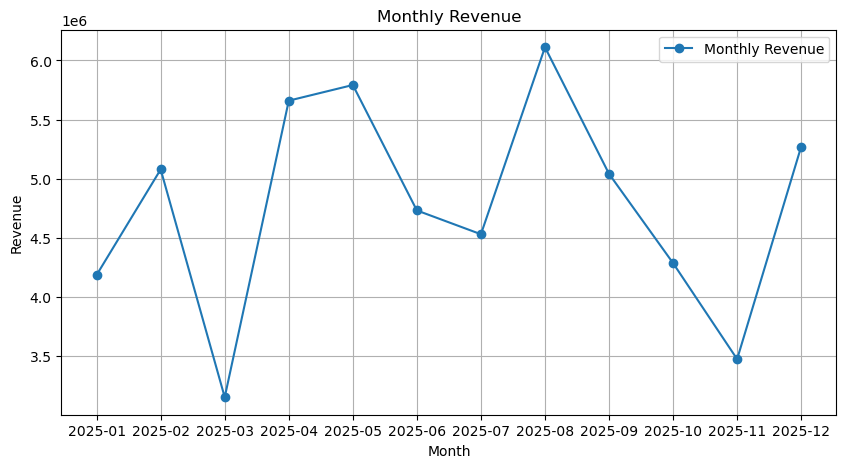

In [8]:
# 1. Plot monthly Revenue as a line chart. Add title, axis labels, markers, grid, and legend.

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\matplotlib_sales_clean_1000 - matplotlib_sales_clean_1000.csv")
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
monthly_revenue = df.groupby(df["Order_Date"].dt.to_period("M"))["Revenue"].sum()
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue.index.astype(str),
         monthly_revenue.values,
         marker="o",
         label="Monthly Revenue"
        )
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.legend()
plt.show()

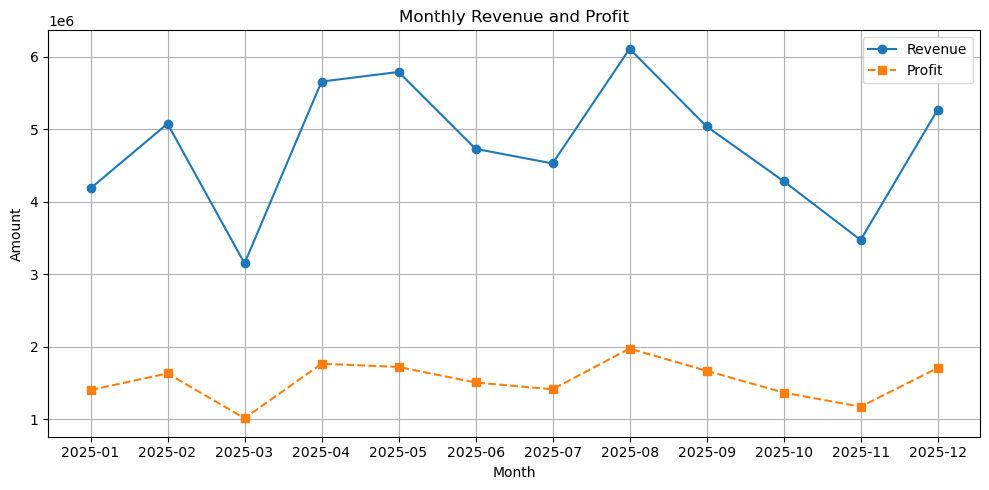

In [9]:
# 2. Plot monthly Revenue and Profit on the same chart using different line styles.

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly_data = df.groupby(
    df["Order_Date"].dt.to_period("M")
)[["Revenue","Profit"]].sum()
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_data.index.astype(str),
    monthly_data["Revenue"],
    marker="o",
    linestyle="-",
    label="Revenue"
)
plt.plot(
    monthly_data.index.astype(str),
    monthly_data["Profit"],
    marker="s",
    linestyle="--",
    label="Profit"
)
plt.title("Monthly Revenue and Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

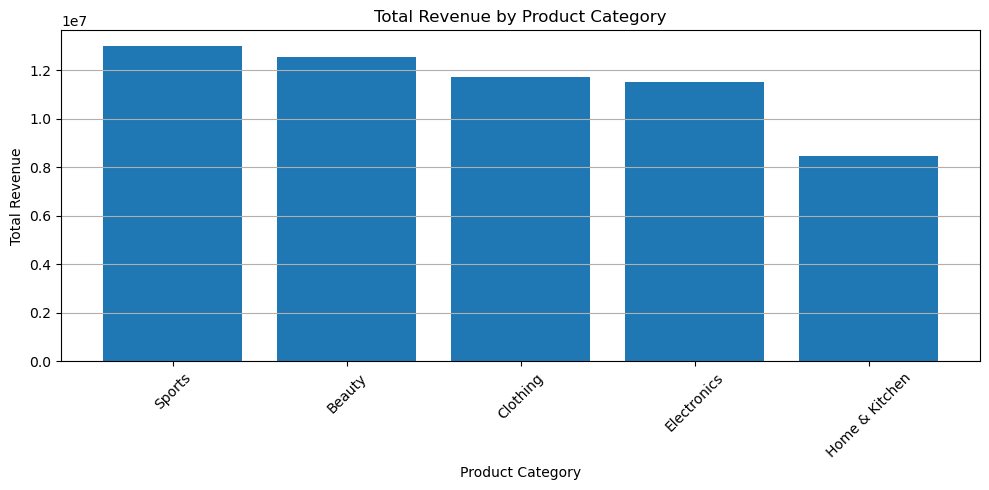

In [10]:
# 3. Create a bar chart of total Revenue by Product_Category and sort the categories from highest to lowest revenue.

import matplotlib.pyplot as plt
category_revenue = df.groupby("Product_Category")["Revenue"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
plt.bar(
    category_revenue.index,
    category_revenue.values
)
plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

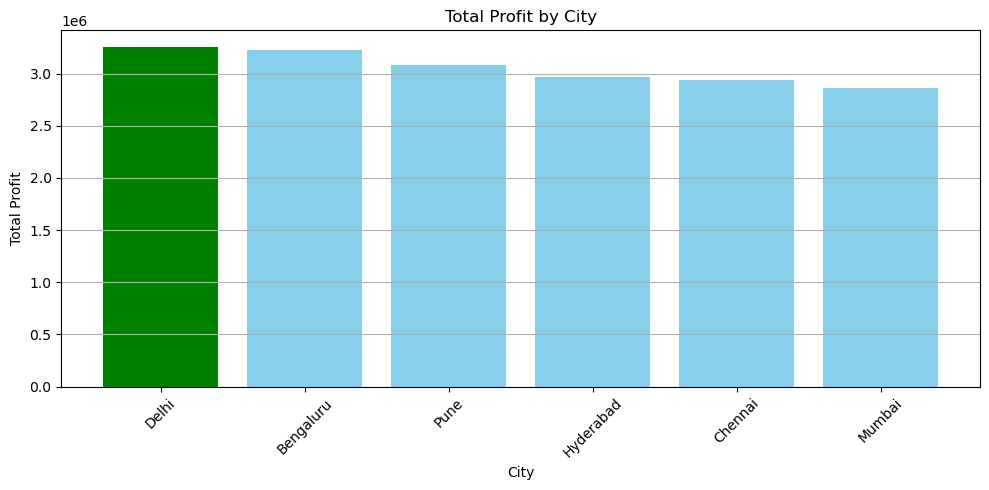

Highest Profit City: Delhi
Highest Profit: 3251311.52


In [15]:
# 4. Create a bar chart of total Profit by City and highlight the city with the highest profit.

city_profit = df.pivot_table(
    index="City",
    values="Profit",
    aggfunc="sum"
).sort_values("Profit",ascending=False)
highest_profit_city=city_profit["Profit"].idxmax()
colors = [
    "green" if city == highest_profit_city else "skyblue"
    for city in city_profit.index
]
plt.figure(figsize=(10,5))
plt.bar(
    city_profit.index,
    city_profit["Profit"],
    color = colors
)
plt.title("Total Profit by City")
plt.xlabel("City")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()
print("Highest Profit City:", highest_profit_city)
print("Highest Profit:", city_profit.loc[highest_profit_city, "Profit"])

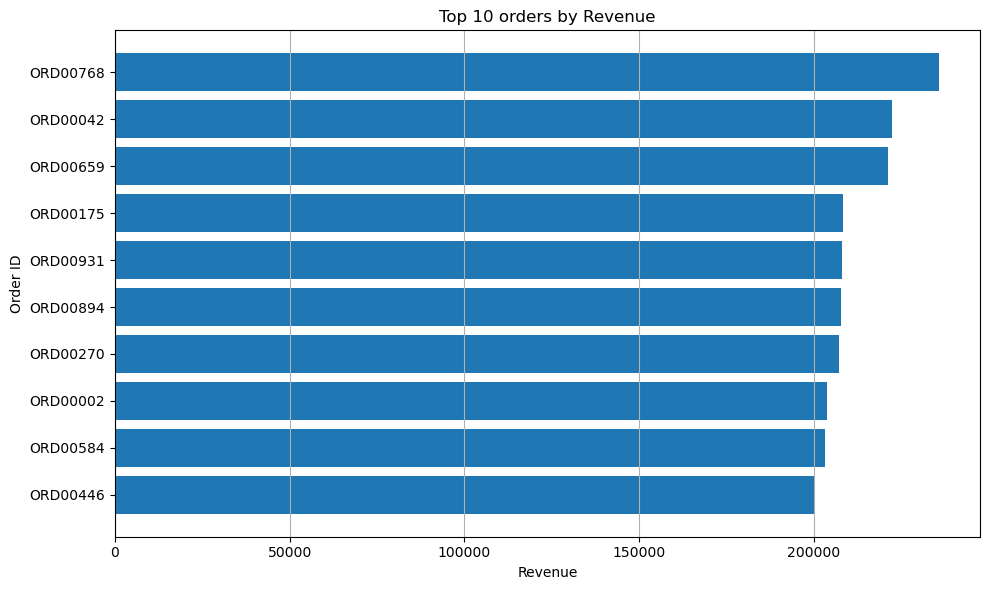

In [16]:
# 5. Create a horizontal bar chart showing the top 10 orders based on Revenue.

top_10_orders= df.sort_values("Revenue", ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.barh(
    top_10_orders["Order_ID"].astype(str),
    top_10_orders["Revenue"]
)
plt.title("Top 10 orders by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Order ID")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

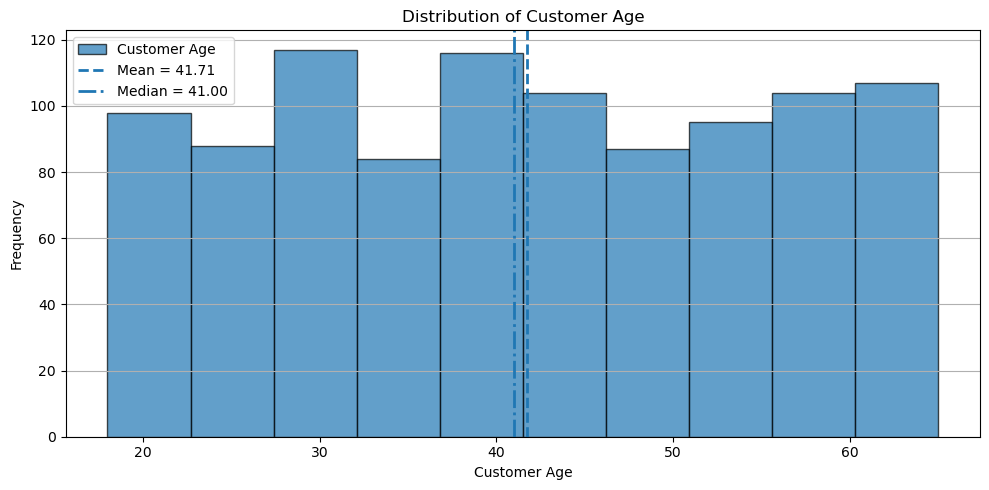

In [17]:
# 6. Create a histogram of Customer_Age using 10 appropriate bins. Add mean and median lines.

import matplotlib.pyplot as plt
mean_age = df["Customer_Age"].mean()
median_age = df["Customer_Age"].median()
plt.figure(figsize=(10, 5))
plt.hist(
    df["Customer_Age"].dropna(),
    bins=10,
    edgecolor="black",
    alpha=0.7,
    label="Customer Age"
)
plt.axvline(
    mean_age,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_age:.2f}"
)
plt.axvline(
    median_age,
    linestyle="-.",
    linewidth=2,
    label=f"Median = {median_age:.2f}"
)
plt.title("Distribution of Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.show()

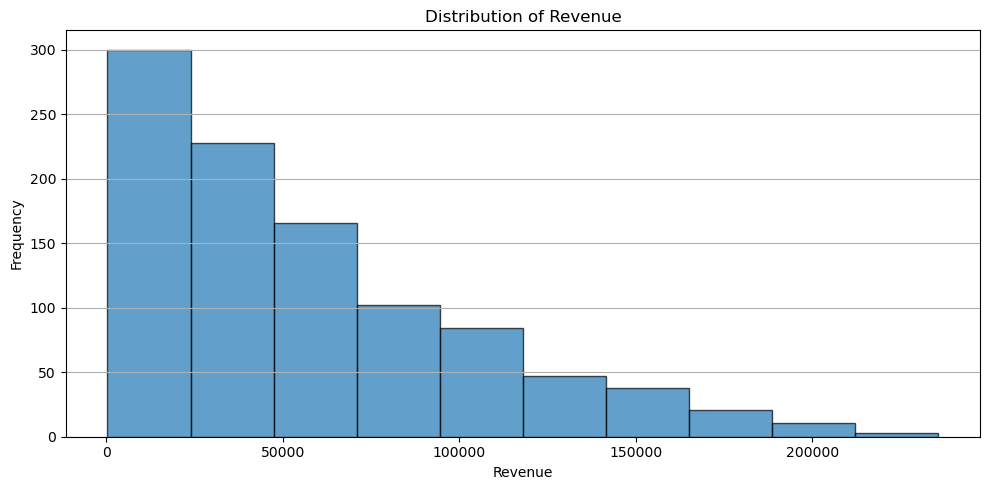

In [18]:
# 7. Create a histogram of Revenue and explain visually whether the distribution appears symmetric or skewed.

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(
    df["Revenue"].dropna(),
    bins=10,
    edgecolor="black",
    alpha=0.7
)
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

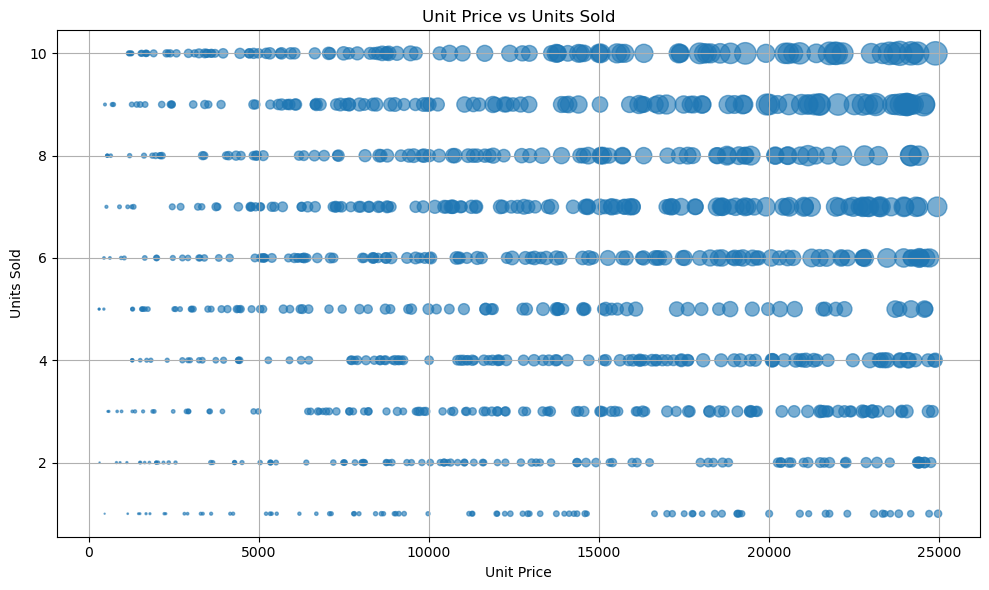

In [19]:
# 8. Create a scatter plot of Unit_Price vs Units_Sold. Use different marker sizes based on Revenue.

import matplotlib.pyplot as plt
marker_size = df["Revenue"] / df["Revenue"].max() * 300
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Unit_Price"],
    df["Units_Sold"],
    s=marker_size,
    alpha=0.6
)
plt.title("Unit Price vs Units Sold")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")
plt.grid(True)
plt.tight_layout()
plt.show()

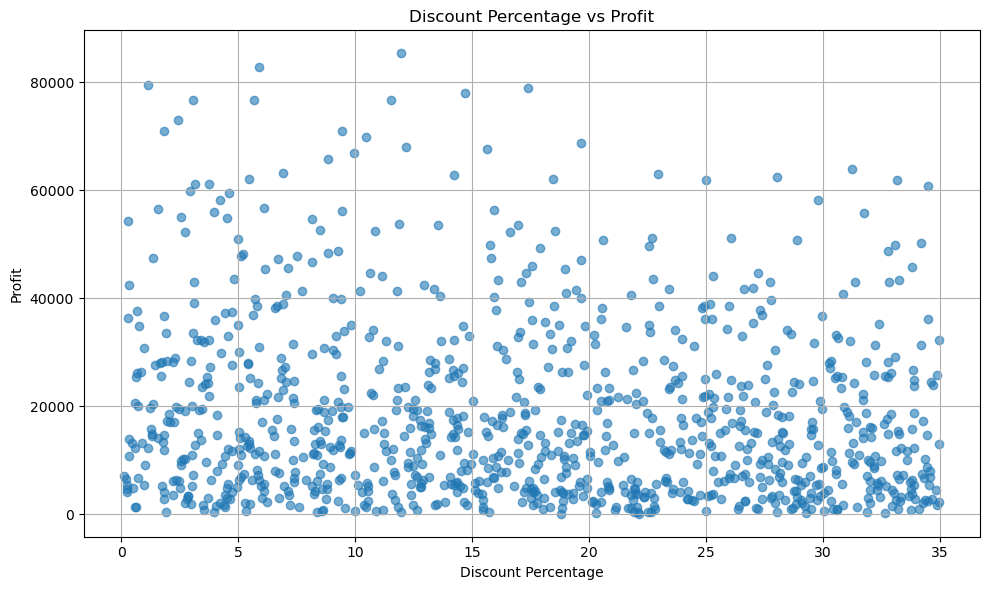

In [20]:
# 9. Create a scatter plot of Discount_Pct vs Profit and determine visually whether higher discounts are associated with lower profit.

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6
)
plt.title("Discount Percentage vs Profit")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

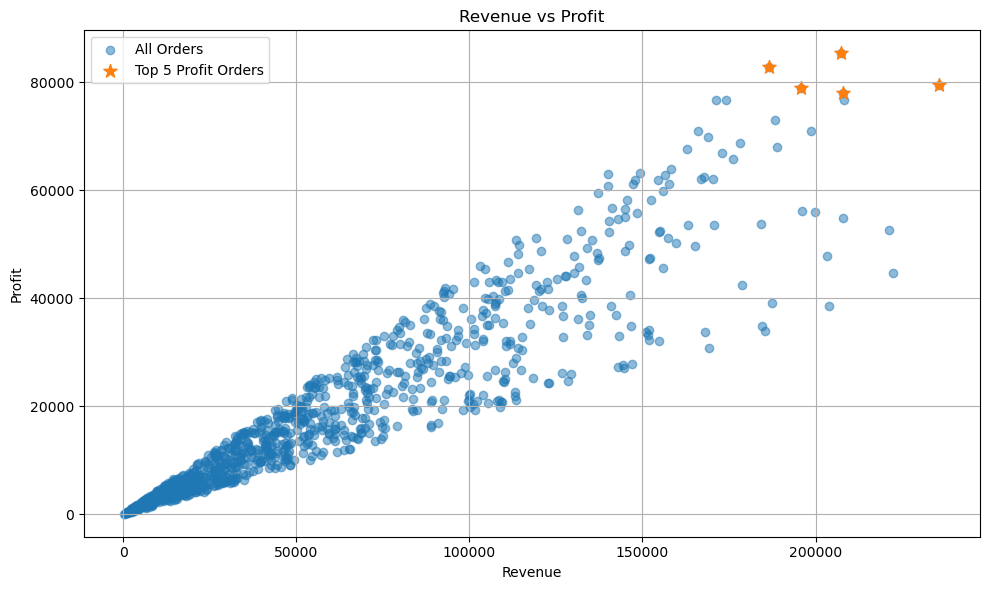

In [21]:
# 10. Create a scatter plot of Revenue vs Profit and highlight the five orders having the highest profit.

import matplotlib.pyplot as plt
top_5_profit = df.nlargest(5, "Profit")
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Revenue"],
    df["Profit"],
    alpha=0.5,
    label="All Orders"
)
plt.scatter(
    top_5_profit["Revenue"],
    top_5_profit["Profit"],
    s=100,
    marker="*",
    label="Top 5 Profit Orders"
)
plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

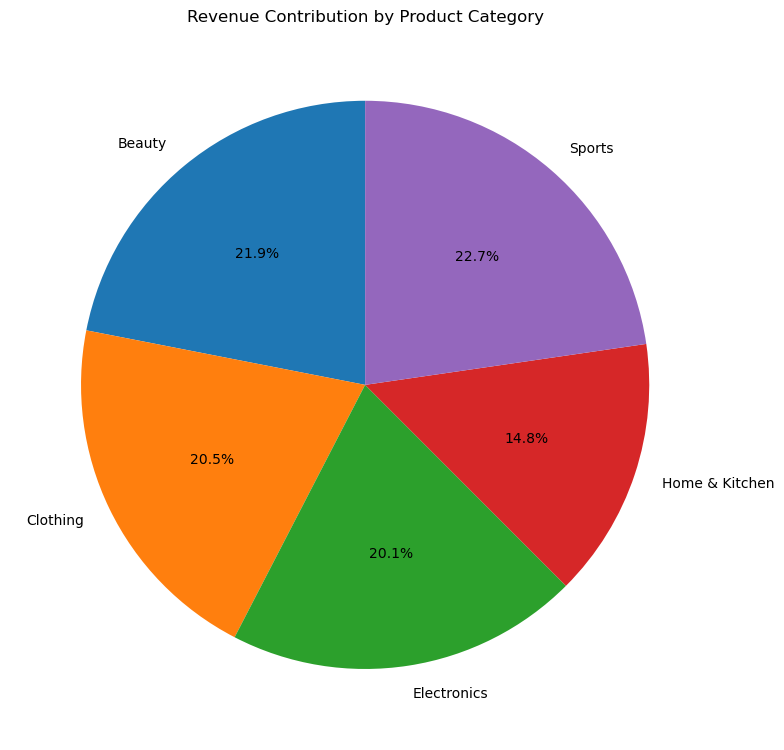

In [22]:
# 11. Create a pie chart of Revenue contribution by Product_Category. Display percentage values.

import matplotlib.pyplot as plt
category_revenue = df.pivot_table(
    index="Product_Category",
    values="Revenue",
    aggfunc="sum"
)
plt.figure(figsize=(8, 8))
plt.pie(
    category_revenue["Revenue"],
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Revenue Contribution by Product Category")
plt.tight_layout()
plt.show()

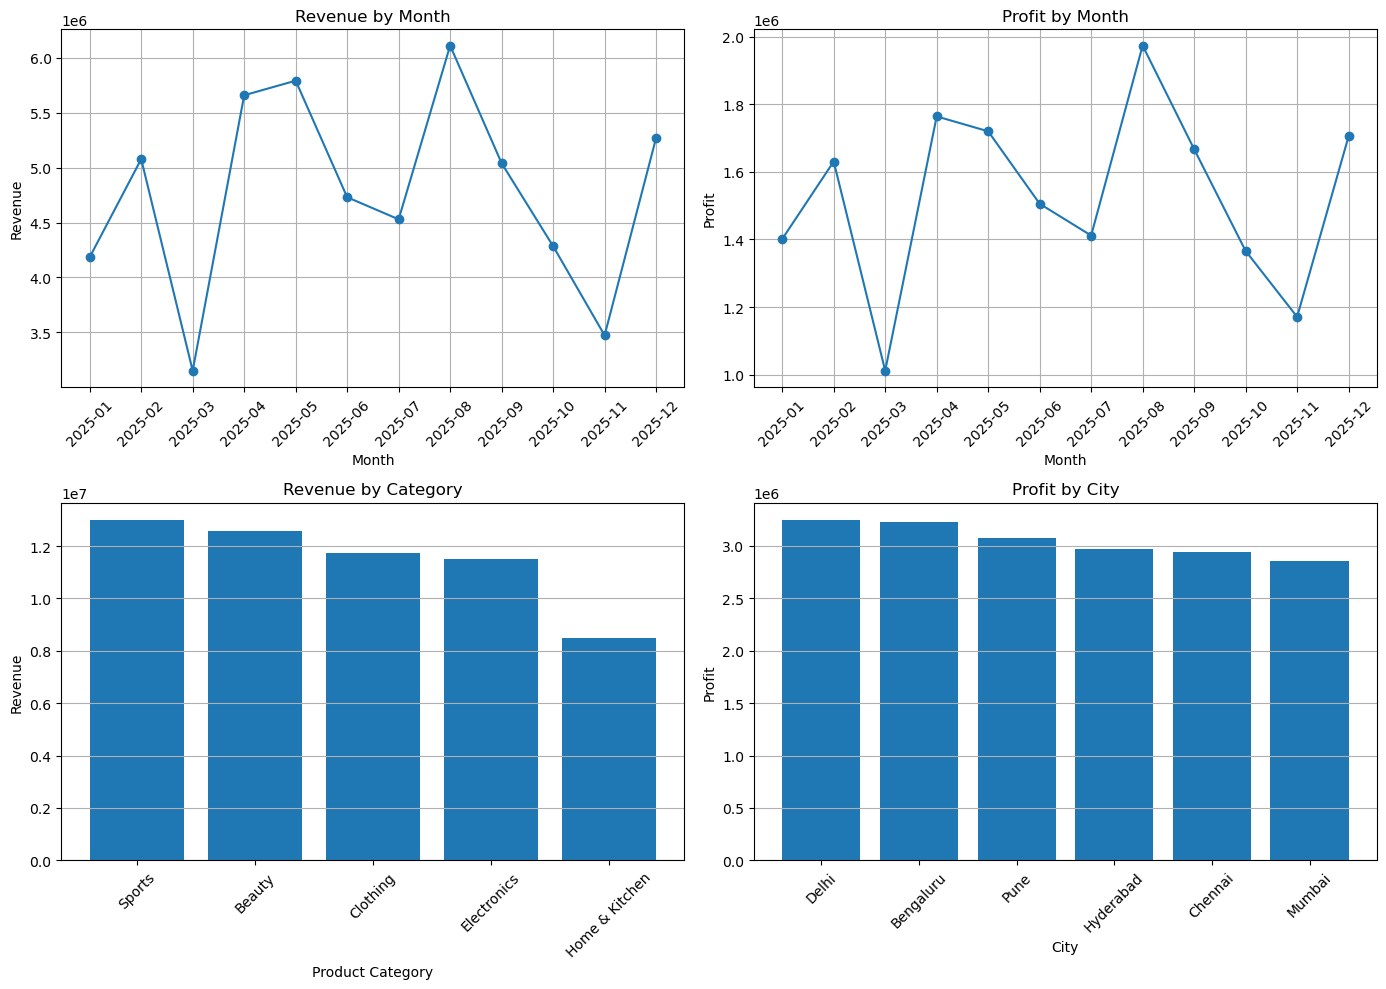

In [23]:
# 12. Create a 2×2 subplot containing:
#o Revenue by month
#o Profit by month
#o Revenue by category
#o Profit by city

import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Monthly Revenue and Profit
monthly_data = df.pivot_table(
    index=df["Order_Date"].dt.to_period("M"),
    values=["Revenue", "Profit"],
    aggfunc="sum"
)

# Revenue by Category
category_revenue = df.pivot_table(
    index="Product_Category",
    values="Revenue",
    aggfunc="sum"
).sort_values("Revenue", ascending=False)

# Profit by City
city_profit = df.pivot_table(
    index="City",
    values="Profit",
    aggfunc="sum"
).sort_values("Profit", ascending=False)


# Create 2×2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Revenue by Month
axes[0, 0].plot(
    monthly_data.index.astype(str),
    monthly_data["Revenue"],
    marker="o"
)
axes[0, 0].set_title("Revenue by Month")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(True)


# 2. Profit by Month
axes[0, 1].plot(
    monthly_data.index.astype(str),
    monthly_data["Profit"],
    marker="o"
)
axes[0, 1].set_title("Profit by Month")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Profit")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].grid(True)


# 3. Revenue by Category
axes[1, 0].bar(
    category_revenue.index,
    category_revenue["Revenue"]
)
axes[1, 0].set_title("Revenue by Category")
axes[1, 0].set_xlabel("Product Category")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(axis="y")


# 4. Profit by City
axes[1, 1].bar(
    city_profit.index,
    city_profit["Profit"]
)
axes[1, 1].set_title("Profit by City")
axes[1, 1].set_xlabel("City")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y")


# Adjust spacing
plt.tight_layout()

plt.show()

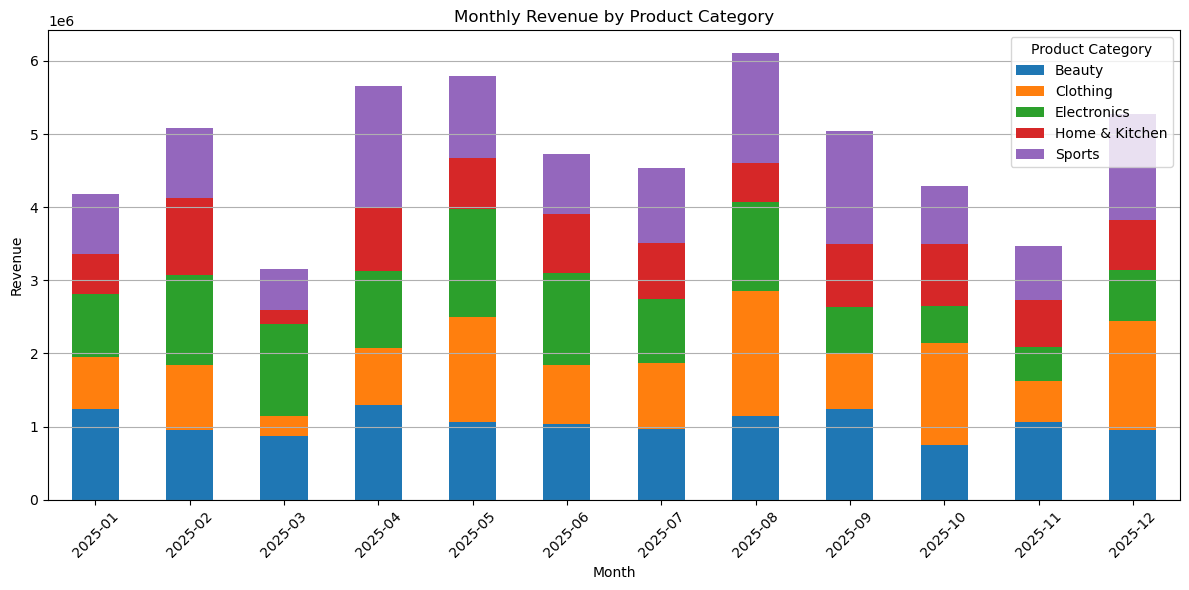

In [24]:
# 13. Create a stacked bar chart showing Revenue by month for each Product_Category.

import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create monthly revenue by Product_Category
monthly_category_revenue = df.pivot_table(
    index=df["Order_Date"].dt.to_period("M"),
    columns="Product_Category",
    values="Revenue",
    aggfunc="sum"
)

# Create stacked bar chart
monthly_category_revenue.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Monthly Revenue by Product Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Product Category")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

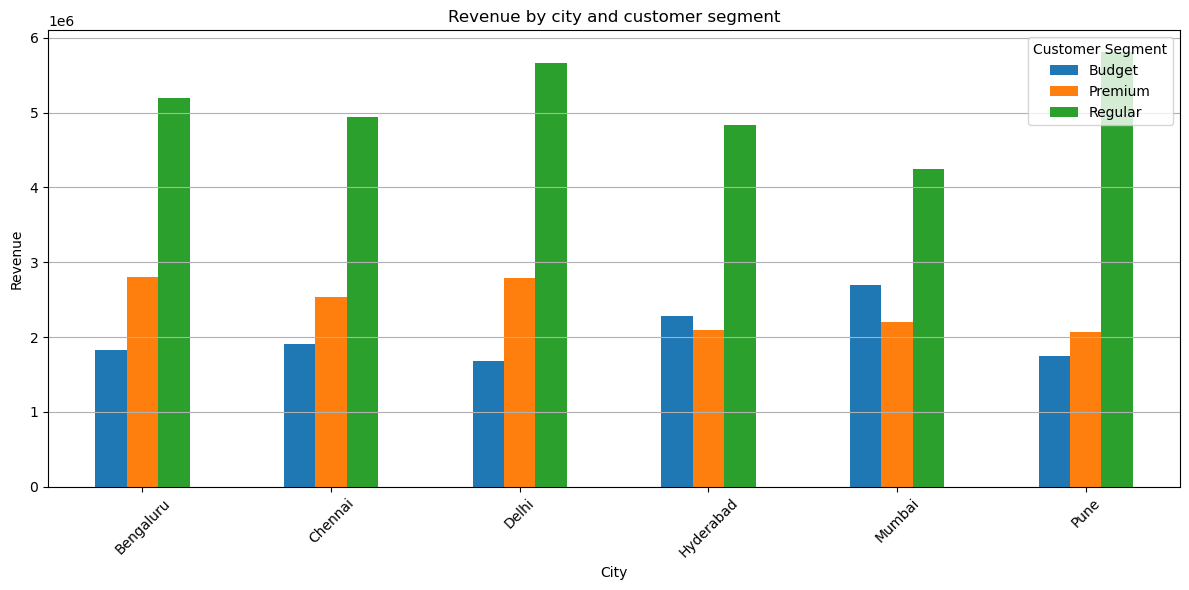

In [29]:
# 14. Create a grouped bar chart comparing Revenue across cities for different customer segments.

import matplotlib.pyplot as plt
city_segment_revenue = df.pivot_table(
    index = "City",
    columns = "Customer_Segment",
    values = "Revenue",
    aggfunc = "sum"
)
city_segment_revenue.plot(
    kind="bar",
    figsize = (12,6)
)
plt.title("Revenue by city and customer segment")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Customer Segment")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

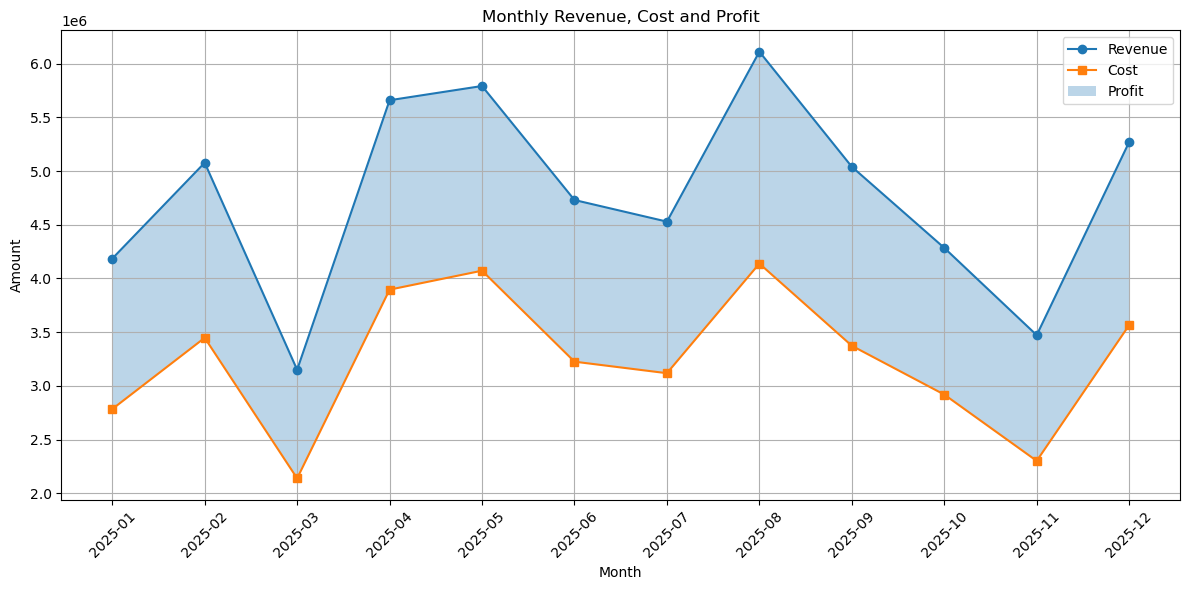

In [30]:
# 15. Plot monthly Revenue and Cost together and shade the area between the two lines to represent Profit.

import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Calculate monthly Revenue and Cost
monthly_data = df.pivot_table(
    index=df["Order_Date"].dt.to_period("M"),
    values=["Revenue", "Cost"],
    aggfunc="sum"
)

# Convert month index to strings
months = monthly_data.index.astype(str)

# Create the chart
plt.figure(figsize=(12, 6))

plt.plot(
    months,
    monthly_data["Revenue"],
    marker="o",
    label="Revenue"
)

plt.plot(
    months,
    monthly_data["Cost"],
    marker="s",
    label="Cost"
)

# Shade the area between Revenue and Cost
plt.fill_between(
    range(len(months)),
    monthly_data["Revenue"],
    monthly_data["Cost"],
    alpha=0.3,
    label="Profit"
)

plt.title("Monthly Revenue, Cost and Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

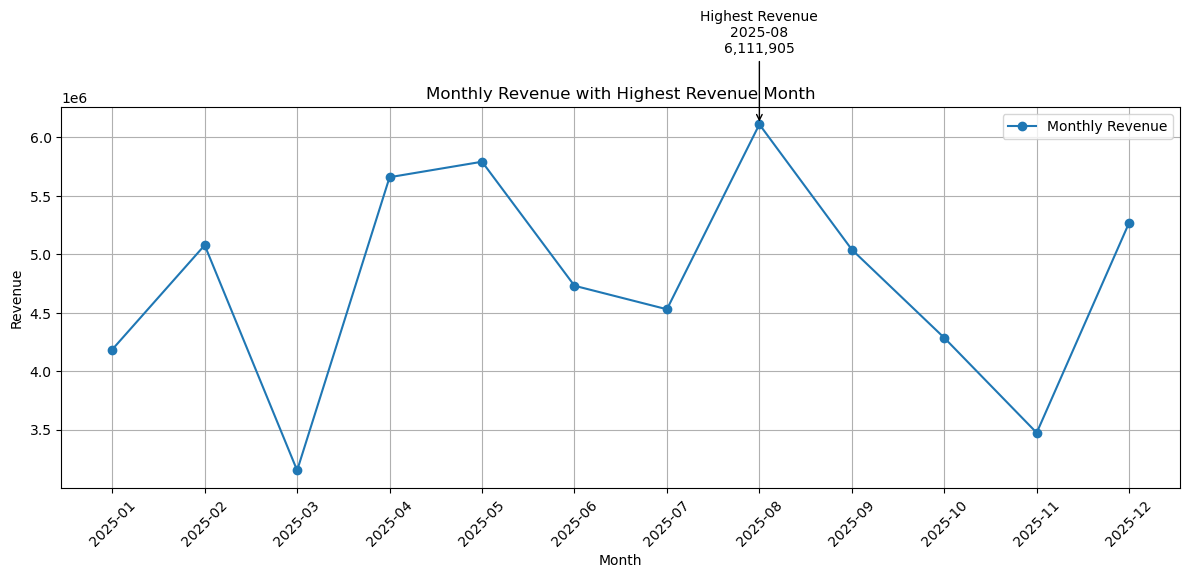

Highest Revenue Month: 2025-08
Highest Revenue: 6111904.58


In [31]:
# 16. Find the month with the highest Revenue and annotate that point on the line chart.

import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Calculate monthly Revenue
monthly_revenue = df.pivot_table(
    index=df["Order_Date"].dt.to_period("M"),
    values="Revenue",
    aggfunc="sum"
)

# Find the month with highest Revenue
highest_revenue_month = monthly_revenue["Revenue"].idxmax()
highest_revenue = monthly_revenue.loc[highest_revenue_month, "Revenue"]

# Convert index to strings for plotting
months = monthly_revenue.index.astype(str)

# Create line chart
plt.figure(figsize=(12, 6))

plt.plot(
    months,
    monthly_revenue["Revenue"],
    marker="o",
    label="Monthly Revenue"
)

# Find position of highest month
highest_position = list(monthly_revenue.index).index(highest_revenue_month)

# Annotate highest Revenue point
plt.annotate(
    f"Highest Revenue\n{highest_revenue_month}\n{highest_revenue:,.0f}",
    xy=(highest_position, highest_revenue),
    xytext=(highest_position, highest_revenue * 1.10),
    arrowprops=dict(arrowstyle="->"),
    ha="center"
)

plt.title("Monthly Revenue with Highest Revenue Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("Highest Revenue Month:", highest_revenue_month)
print("Highest Revenue:", highest_revenue)

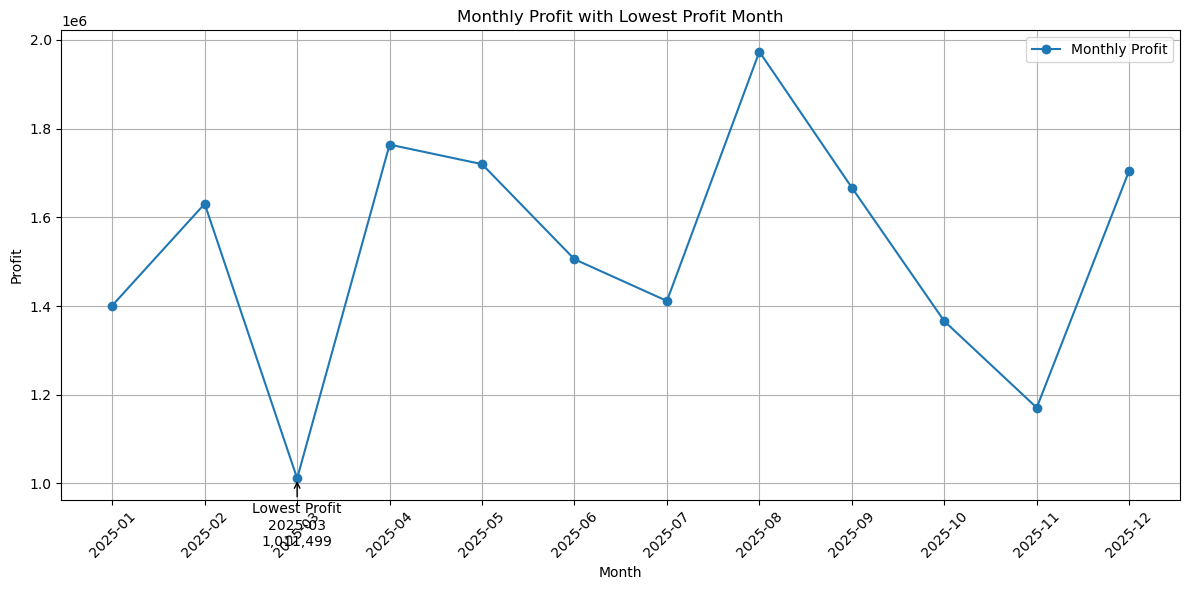

Lowest Profit Month: 2025-03
Lowest Profit: 1011498.74


In [32]:
# 17. Find the month with the lowest Profit and annotate it on the visualization.

import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Calculate monthly Profit
monthly_profit = df.pivot_table(
    index=df["Order_Date"].dt.to_period("M"),
    values="Profit",
    aggfunc="sum"
)

# Find the month with the lowest Profit
lowest_profit_month = monthly_profit["Profit"].idxmin()
lowest_profit = monthly_profit.loc[lowest_profit_month, "Profit"]

# Convert months to strings for plotting
months = monthly_profit.index.astype(str)

# Create line chart
plt.figure(figsize=(12, 6))

plt.plot(
    months,
    monthly_profit["Profit"],
    marker="o",
    label="Monthly Profit"
)

# Find position of lowest profit month
lowest_position = list(monthly_profit.index).index(lowest_profit_month)

# Annotate lowest Profit point
plt.annotate(
    f"Lowest Profit\n{lowest_profit_month}\n{lowest_profit:,.0f}",
    xy=(lowest_position, lowest_profit),
    xytext=(lowest_position, lowest_profit * 0.85),
    arrowprops=dict(arrowstyle="->"),
    ha="center"
)

plt.title("Monthly Profit with Lowest Profit Month")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("Lowest Profit Month:", lowest_profit_month)
print("Lowest Profit:", lowest_profit)

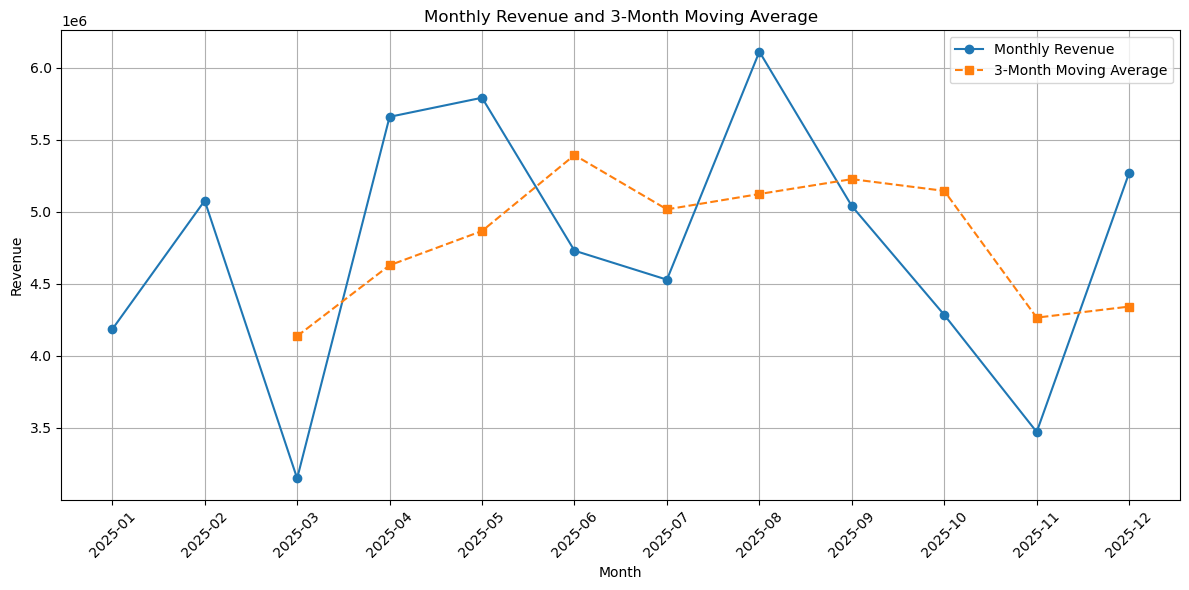

In [33]:
# 18. Create a line chart of monthly Revenue and calculate a 3-month moving average. Plot both lines together.

import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Calculate monthly Revenue
monthly_revenue = df.pivot_table(
    index=df["Order_Date"].dt.to_period("M"),
    values="Revenue",
    aggfunc="sum"
)

# Calculate 3-month moving average
monthly_revenue["Moving_Average_3M"] = (
    monthly_revenue["Revenue"].rolling(window=3).mean()
)

# Convert months to strings for plotting
months = monthly_revenue.index.astype(str)

# Create line chart
plt.figure(figsize=(12, 6))

plt.plot(
    months,
    monthly_revenue["Revenue"],
    marker="o",
    label="Monthly Revenue"
)

plt.plot(
    months,
    monthly_revenue["Moving_Average_3M"],
    marker="s",
    linestyle="--",
    label="3-Month Moving Average"
)

plt.title("Monthly Revenue and 3-Month Moving Average")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

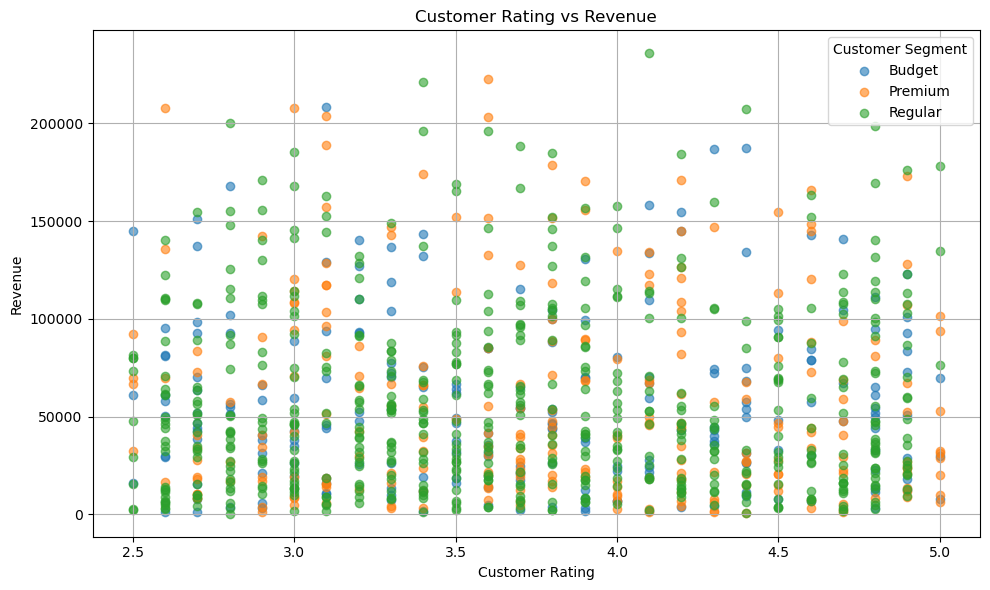

In [34]:
# 19. Create a scatter plot between Customer_Rating and Revenue. Use Customer_Segment to visually distinguish the points.

import matplotlib.pyplot as plt

# Get unique customer segments
segments = df["Customer_Segment"].dropna().unique()

plt.figure(figsize=(10, 6))

# Plot each customer segment separately
for segment in segments:
    segment_data = df[df["Customer_Segment"] == segment]

    plt.scatter(
        segment_data["Customer_Rating"],
        segment_data["Revenue"],
        alpha=0.6,
        label=segment
    )

plt.title("Customer Rating vs Revenue")
plt.xlabel("Customer Rating")
plt.ylabel("Revenue")
plt.grid(True)
plt.legend(title="Customer Segment")

plt.tight_layout()
plt.show()

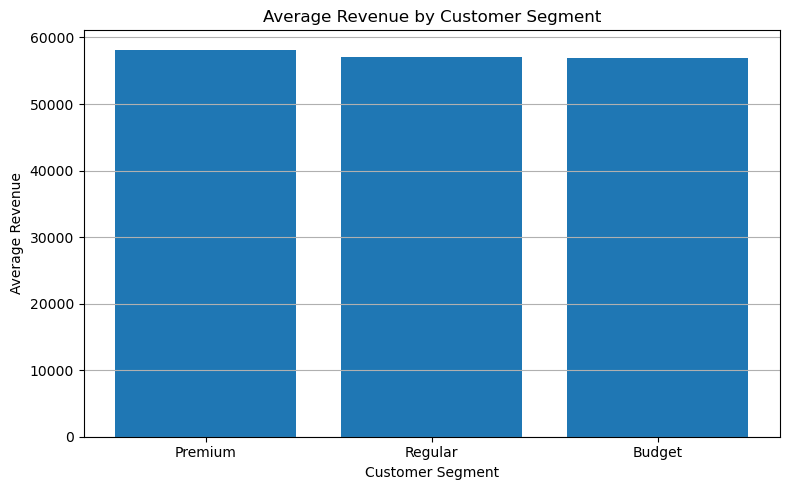

In [35]:
# 20. Create a visualization comparing the average Revenue of Premium, Regular, and Budget customers.

import matplotlib.pyplot as plt

# Calculate average Revenue by Customer Segment
segment_revenue = df.pivot_table(
    index="Customer_Segment",
    values="Revenue",
    aggfunc="mean"
)

# Keep only Premium, Regular, and Budget
segment_revenue = segment_revenue.loc[
    ["Premium", "Regular", "Budget"]
]

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    segment_revenue.index,
    segment_revenue["Revenue"]
)

plt.title("Average Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Revenue")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_3296\1154609413.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


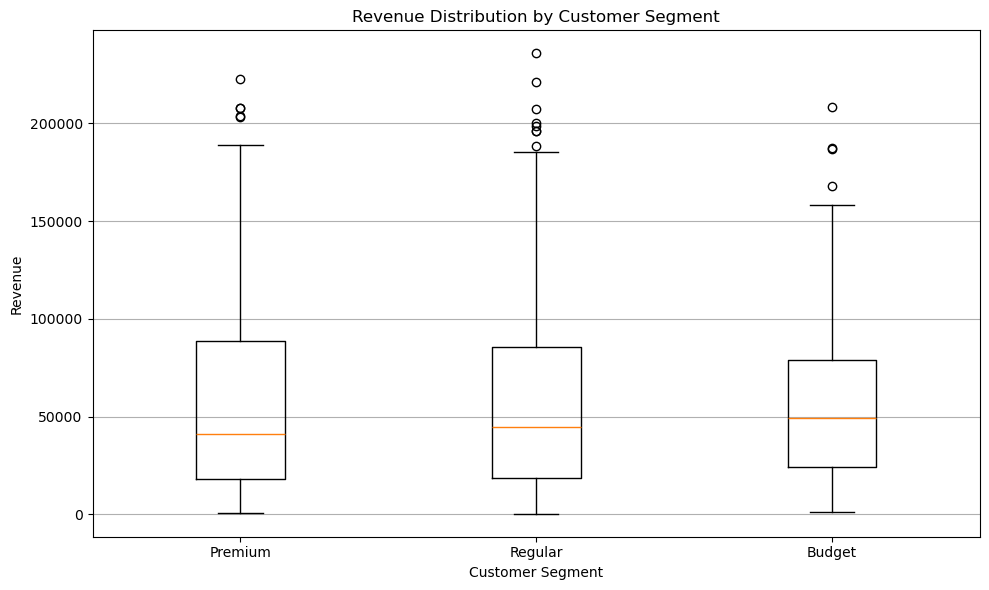

In [36]:
# 21. Create a boxplot of Revenue for each Customer_Segment. Compare the distributions visually.

import matplotlib.pyplot as plt

# Create Revenue data for each Customer Segment
premium = df[df["Customer_Segment"] == "Premium"]["Revenue"].dropna()
regular = df[df["Customer_Segment"] == "Regular"]["Revenue"].dropna()
budget = df[df["Customer_Segment"] == "Budget"]["Revenue"].dropna()

# Create boxplot
plt.figure(figsize=(10, 6))

plt.boxplot(
    [premium, regular, budget],
    labels=["Premium", "Regular", "Budget"]
)

plt.title("Revenue Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_3296\754531958.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


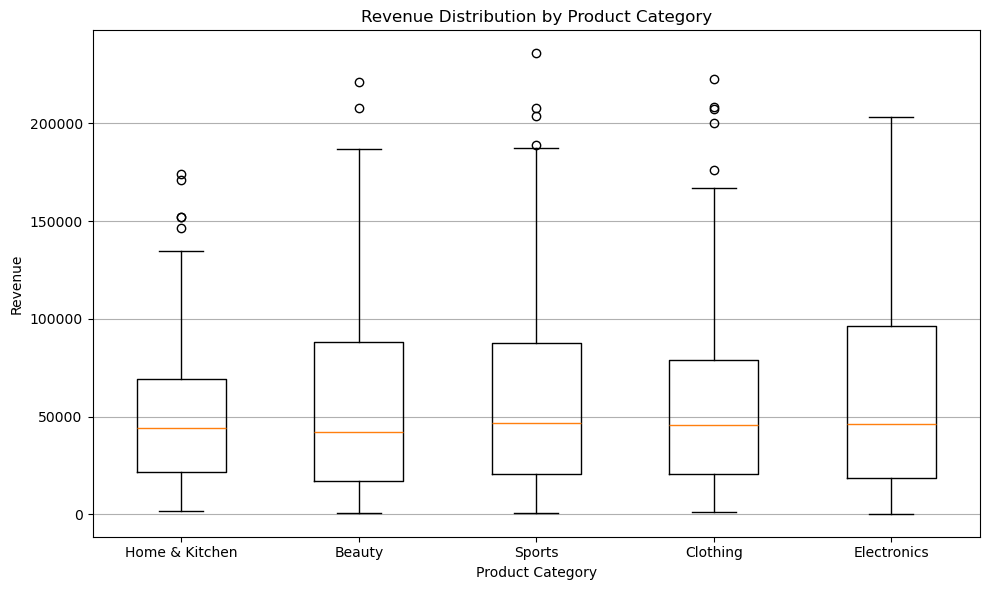

In [37]:
# 22. Create boxplots of Revenue for each Product_Category and identify which category has the largest spread.

import matplotlib.pyplot as plt

# Get Revenue for each Product Category
categories = df["Product_Category"].dropna().unique()

category_revenue = [
    df[df["Product_Category"] == category]["Revenue"].dropna()
    for category in categories
]

# Create boxplot
plt.figure(figsize=(10, 6))

plt.boxplot(
    category_revenue,
    labels=categories
)

plt.title("Revenue Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

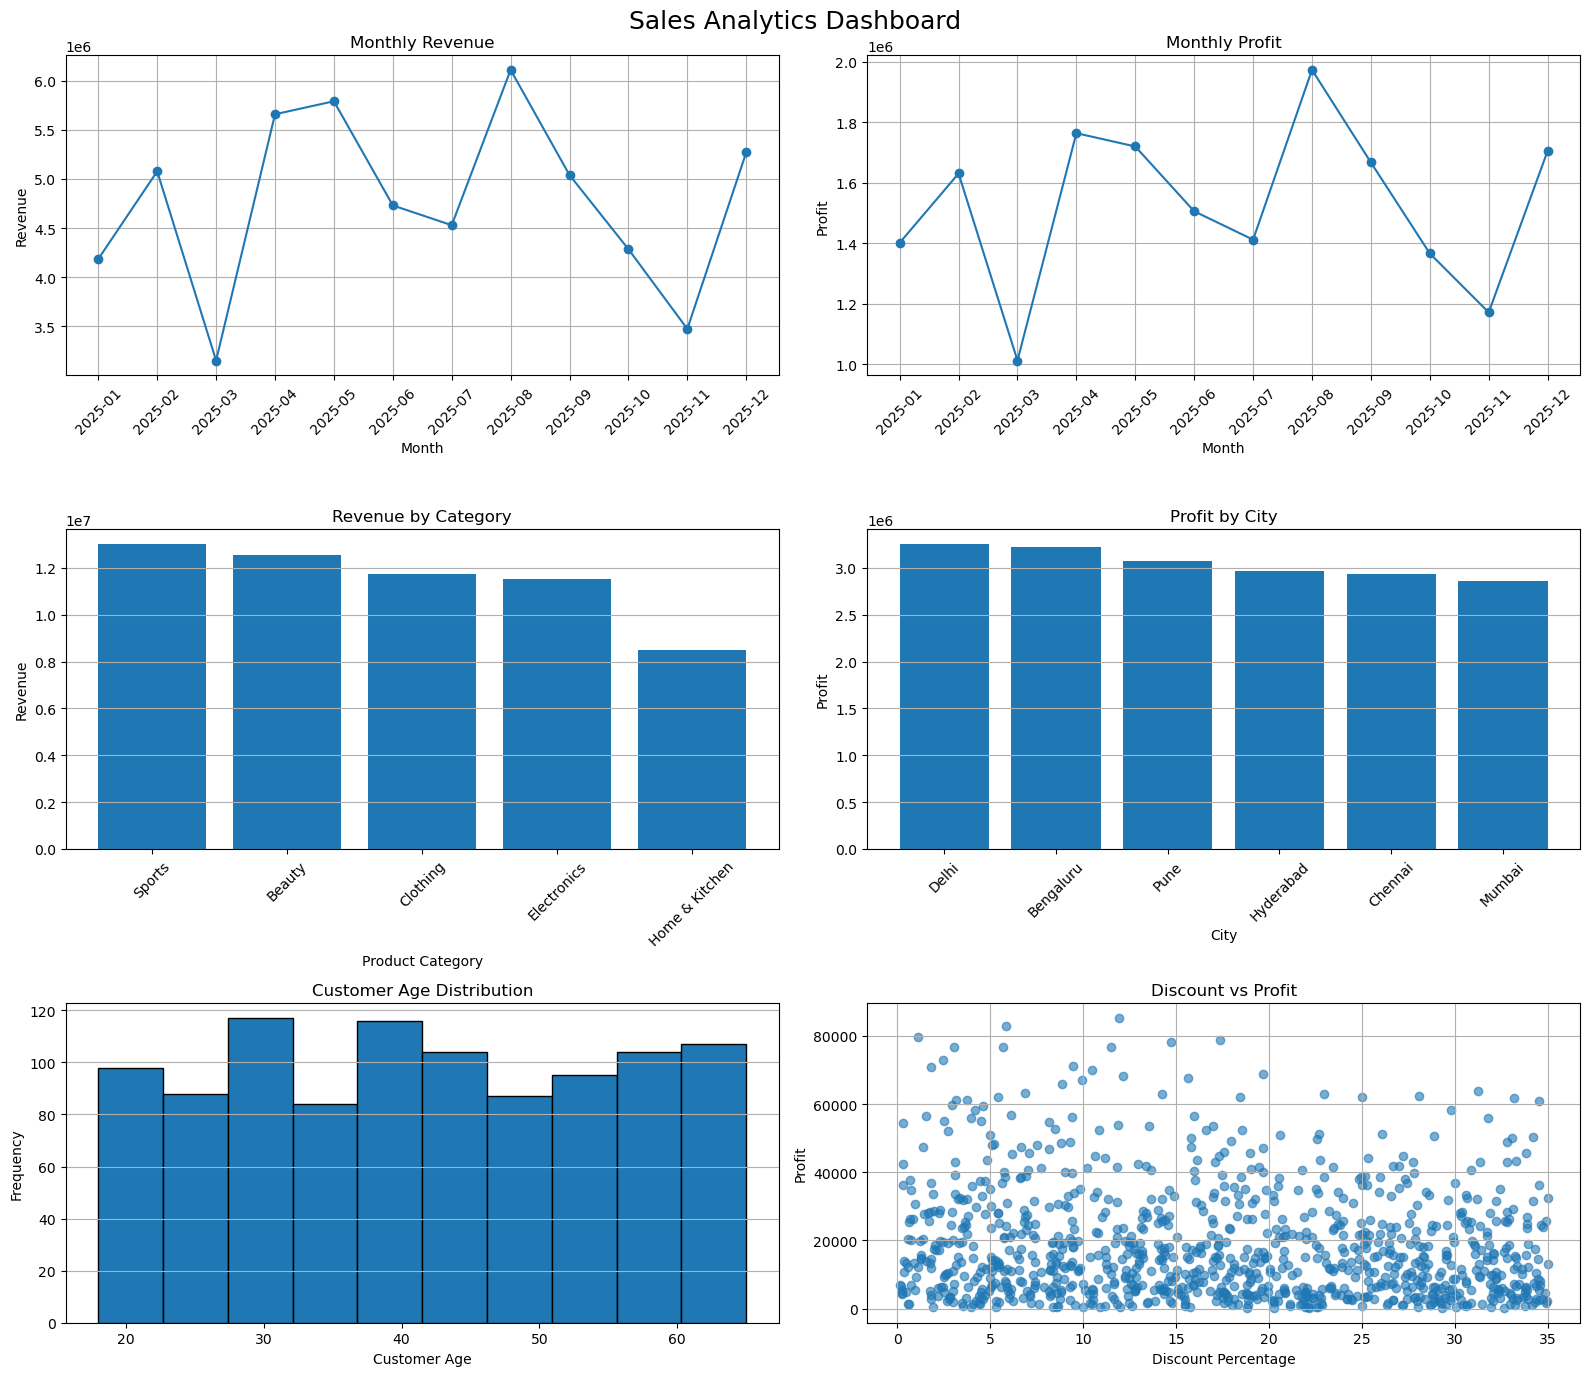

In [38]:
# 23. Create a 3×2 Matplotlib dashboard containing:
#o Monthly revenue
#o Monthly profit
#o Category revenue
#o City profit
#o Customer-age distribution
#o Discount vs profit

import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Monthly Revenue and Profit
monthly_data = df.pivot_table(
    index=df["Order_Date"].dt.to_period("M"),
    values=["Revenue", "Profit"],
    aggfunc="sum"
)

# Revenue by Category
category_revenue = df.pivot_table(
    index="Product_Category",
    values="Revenue",
    aggfunc="sum"
).sort_values("Revenue", ascending=False)

# Profit by City
city_profit = df.pivot_table(
    index="City",
    values="Profit",
    aggfunc="sum"
).sort_values("Profit", ascending=False)


# Create 3×2 dashboard
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# 1. Monthly Revenue
axes[0, 0].plot(
    monthly_data.index.astype(str),
    monthly_data["Revenue"],
    marker="o"
)
axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(True)


# 2. Monthly Profit
axes[0, 1].plot(
    monthly_data.index.astype(str),
    monthly_data["Profit"],
    marker="o"
)
axes[0, 1].set_title("Monthly Profit")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Profit")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].grid(True)


# 3. Category Revenue
axes[1, 0].bar(
    category_revenue.index,
    category_revenue["Revenue"]
)
axes[1, 0].set_title("Revenue by Category")
axes[1, 0].set_xlabel("Product Category")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(axis="y")


# 4. City Profit
axes[1, 1].bar(
    city_profit.index,
    city_profit["Profit"]
)
axes[1, 1].set_title("Profit by City")
axes[1, 1].set_xlabel("City")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y")


# 5. Customer Age Distribution
axes[2, 0].hist(
    df["Customer_Age"].dropna(),
    bins=10,
    edgecolor="black"
)
axes[2, 0].set_title("Customer Age Distribution")
axes[2, 0].set_xlabel("Customer Age")
axes[2, 0].set_ylabel("Frequency")
axes[2, 0].grid(axis="y")


# 6. Discount vs Profit
axes[2, 1].scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6
)
axes[2, 1].set_title("Discount vs Profit")
axes[2, 1].set_xlabel("Discount Percentage")
axes[2, 1].set_ylabel("Profit")
axes[2, 1].grid(True)


# Overall dashboard title
fig.suptitle(
    "Sales Analytics Dashboard",
    fontsize=18
)

plt.tight_layout()
plt.show()

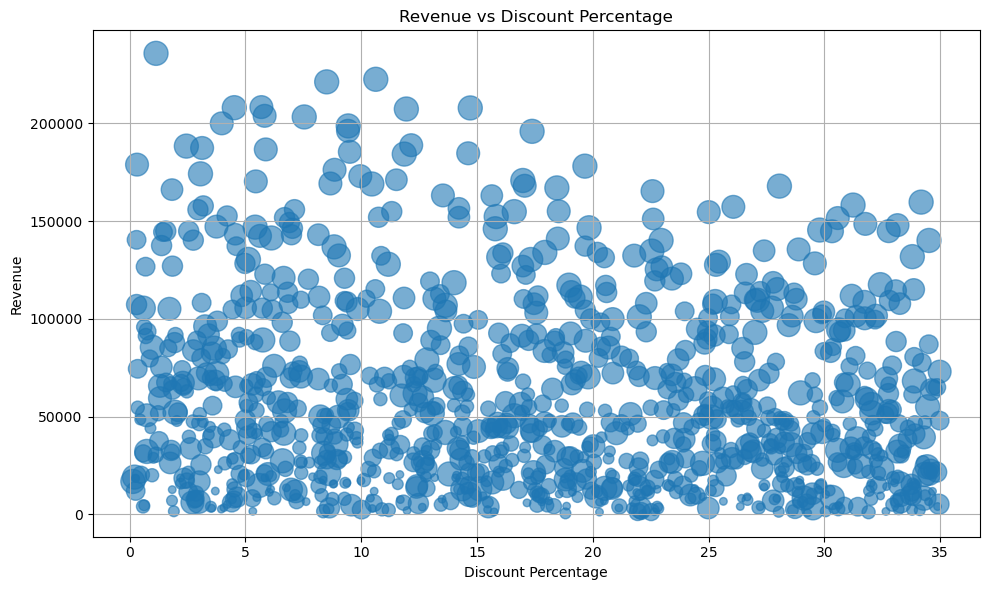

In [39]:
# 24. Create a chart showing Revenue vs Discount_Pct and use marker size to represent Units_Sold.

import matplotlib.pyplot as plt

# Create marker sizes based on Units_Sold
marker_size = df["Units_Sold"] / df["Units_Sold"].max() * 300

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount_Pct"],
    df["Revenue"],
    s=marker_size,
    alpha=0.6
)

plt.title("Revenue vs Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Revenue")
plt.grid(True)

plt.tight_layout()
plt.show()

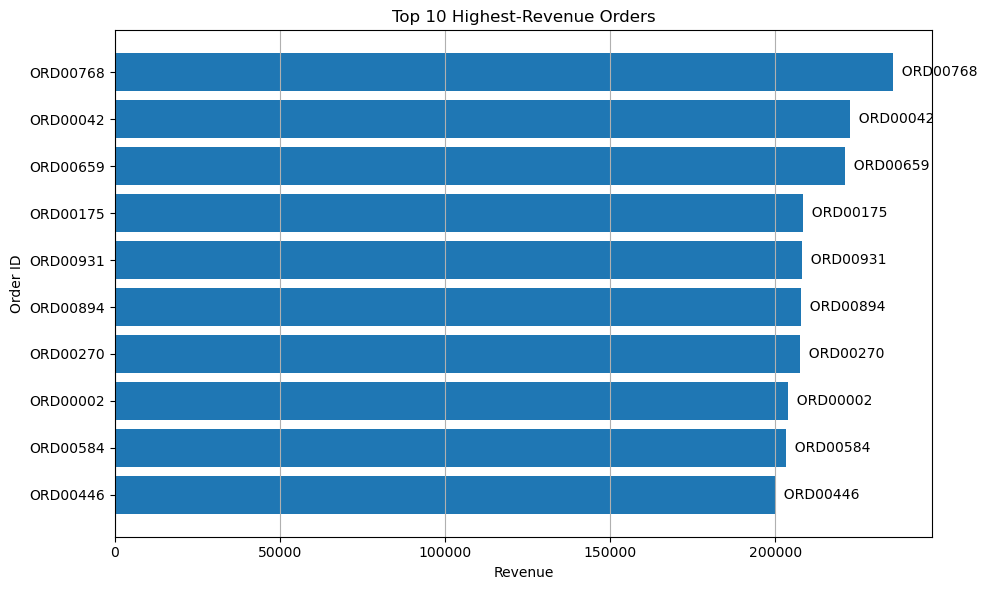

In [40]:
# 25. Identify the top 10 highest-revenue orders and visualize them using a horizontal bar chart. Display the Order_ID beside each bar.

import matplotlib.pyplot as plt

# Find the top 10 highest-revenue orders
top_10_orders = df.nlargest(10, "Revenue").sort_values("Revenue")

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_orders["Order_ID"].astype(str),
    top_10_orders["Revenue"]
)

plt.title("Top 10 Highest-Revenue Orders")
plt.xlabel("Revenue")
plt.ylabel("Order ID")

# Display Order_ID beside each bar
for i, (order_id, revenue) in enumerate(
    zip(top_10_orders["Order_ID"], top_10_orders["Revenue"])
):
    plt.text(
        revenue,
        i,
        f"  {order_id}",
        va="center"
    )

plt.grid(axis="x")

plt.tight_layout()
plt.show()

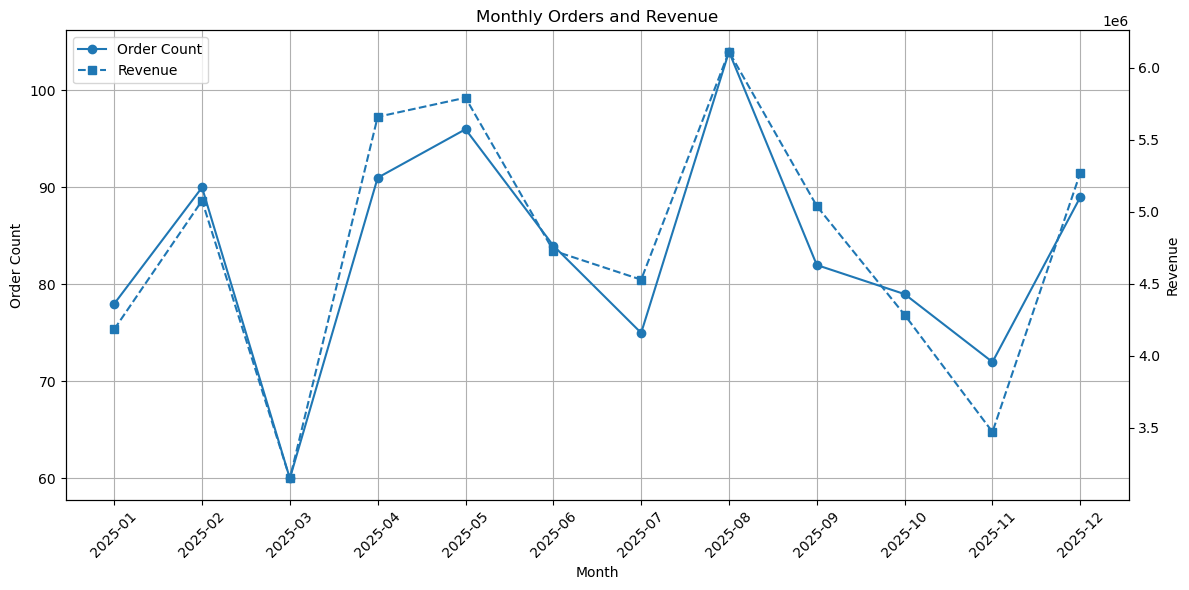

In [41]:
# 26. Create a visualization showing monthly Orders and Revenue using two Y-axes. Use the first Y-axis for order count and the second for revenue.

import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Calculate monthly Orders and Revenue
monthly_data = df.pivot_table(
    index=df["Order_Date"].dt.to_period("M"),
    values="Revenue",
    aggfunc=["count", "sum"]
)

# Rename columns
monthly_data.columns = ["Order_Count", "Revenue"]

# Create x-axis labels
months = monthly_data.index.astype(str)

# Create figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# First Y-axis: Order Count
ax1.plot(
    months,
    monthly_data["Order_Count"],
    marker="o",
    label="Order Count"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Order Count")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True)

# Second Y-axis: Revenue
ax2 = ax1.twinx()

ax2.plot(
    months,
    monthly_data["Revenue"],
    marker="s",
    linestyle="--",
    label="Revenue"
)

ax2.set_ylabel("Revenue")

# Title
plt.title("Monthly Orders and Revenue")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

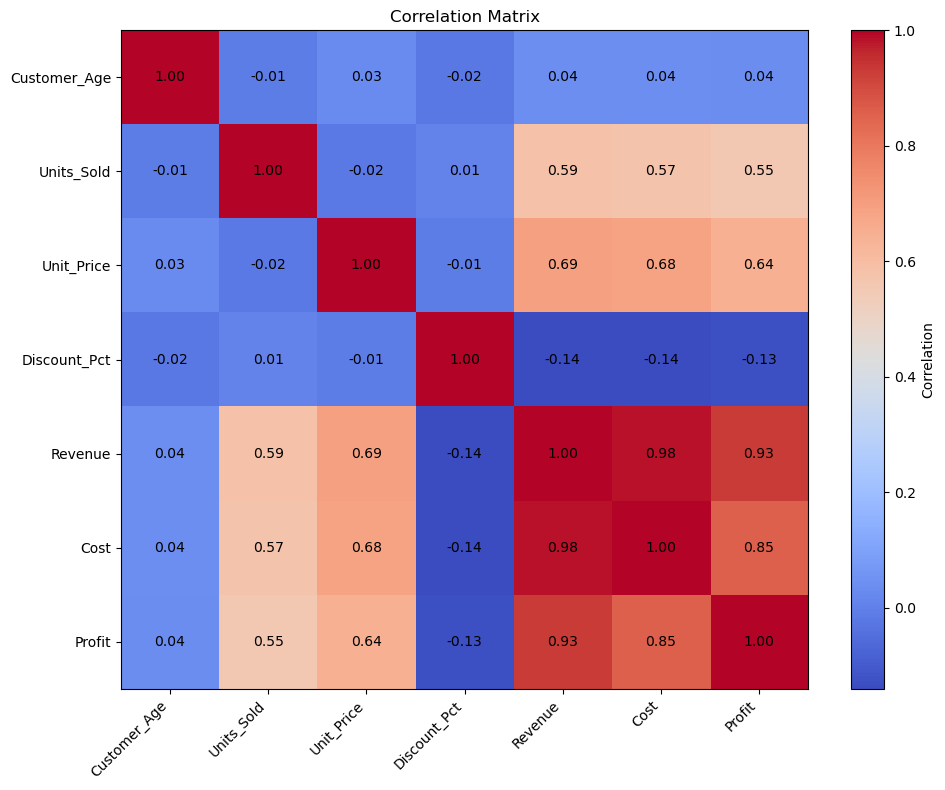

In [42]:
# 27. Create a heatmap-style visualization using Matplotlib only for the correlation matrix of:
# Customer_Age, Units_Sold, Unit_Price, Discount_Pct, Revenue, Cost, and Profit.

import matplotlib.pyplot as plt

# Select required columns
corr_data = df[
    [
        "Customer_Age",
        "Units_Sold",
        "Unit_Price",
        "Discount_Pct",
        "Revenue",
        "Cost",
        "Profit"
    ]
]

# Calculate correlation matrix
correlation_matrix = corr_data.corr()

# Create heatmap-style visualization
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

# Add color bar
plt.colorbar(label="Correlation")

# Add labels
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Display correlation values inside the cells
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

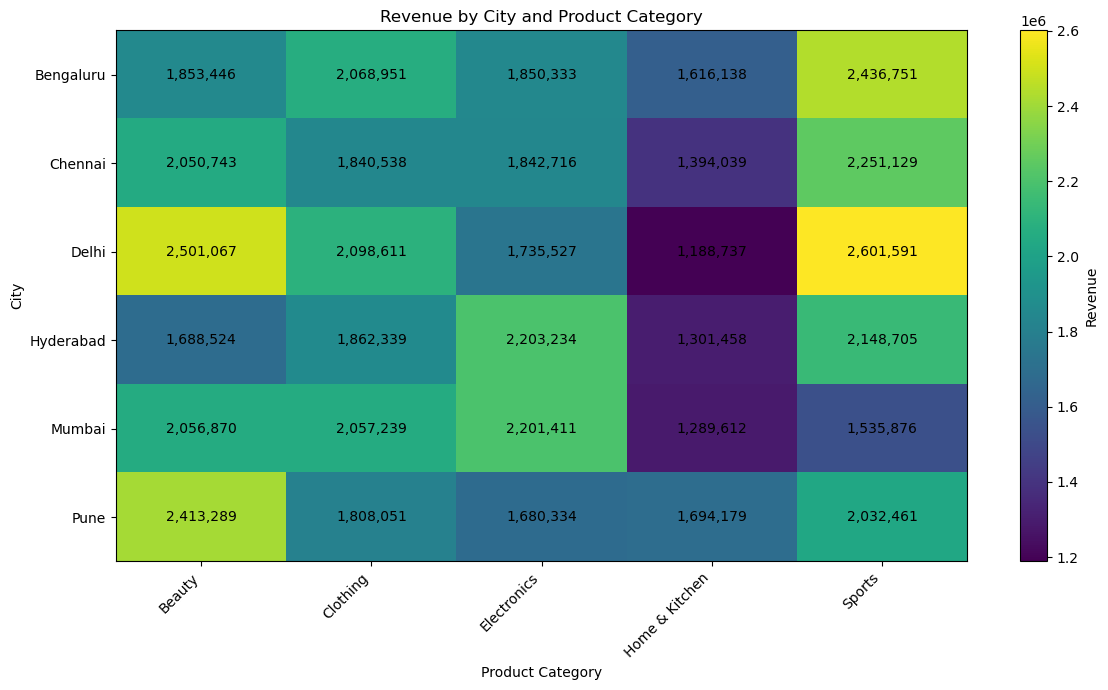

In [43]:
# 28. Create a dashboard comparing City × Product_Category Revenue. Use a suitable visualization to show which combinations generate the highest revenue.

import matplotlib.pyplot as plt

# Calculate Revenue by City and Product Category
city_category_revenue = df.pivot_table(
    index="City",
    columns="Product_Category",
    values="Revenue",
    aggfunc="sum"
)

# Create heatmap
plt.figure(figsize=(12, 7))

plt.imshow(
    city_category_revenue,
    aspect="auto"
)

# Add color bar
plt.colorbar(label="Revenue")

# Add labels
plt.xticks(
    range(len(city_category_revenue.columns)),
    city_category_revenue.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(city_category_revenue.index)),
    city_category_revenue.index
)

# Display revenue values inside cells
for i in range(len(city_category_revenue.index)):
    for j in range(len(city_category_revenue.columns)):
        value = city_category_revenue.iloc[i, j]

        if not pd.isna(value):
            plt.text(
                j,
                i,
                f"{value:,.0f}",
                ha="center",
                va="center"
            )

plt.title("Revenue by City and Product Category")
plt.xlabel("Product Category")
plt.ylabel("City")

plt.tight_layout()
plt.show()

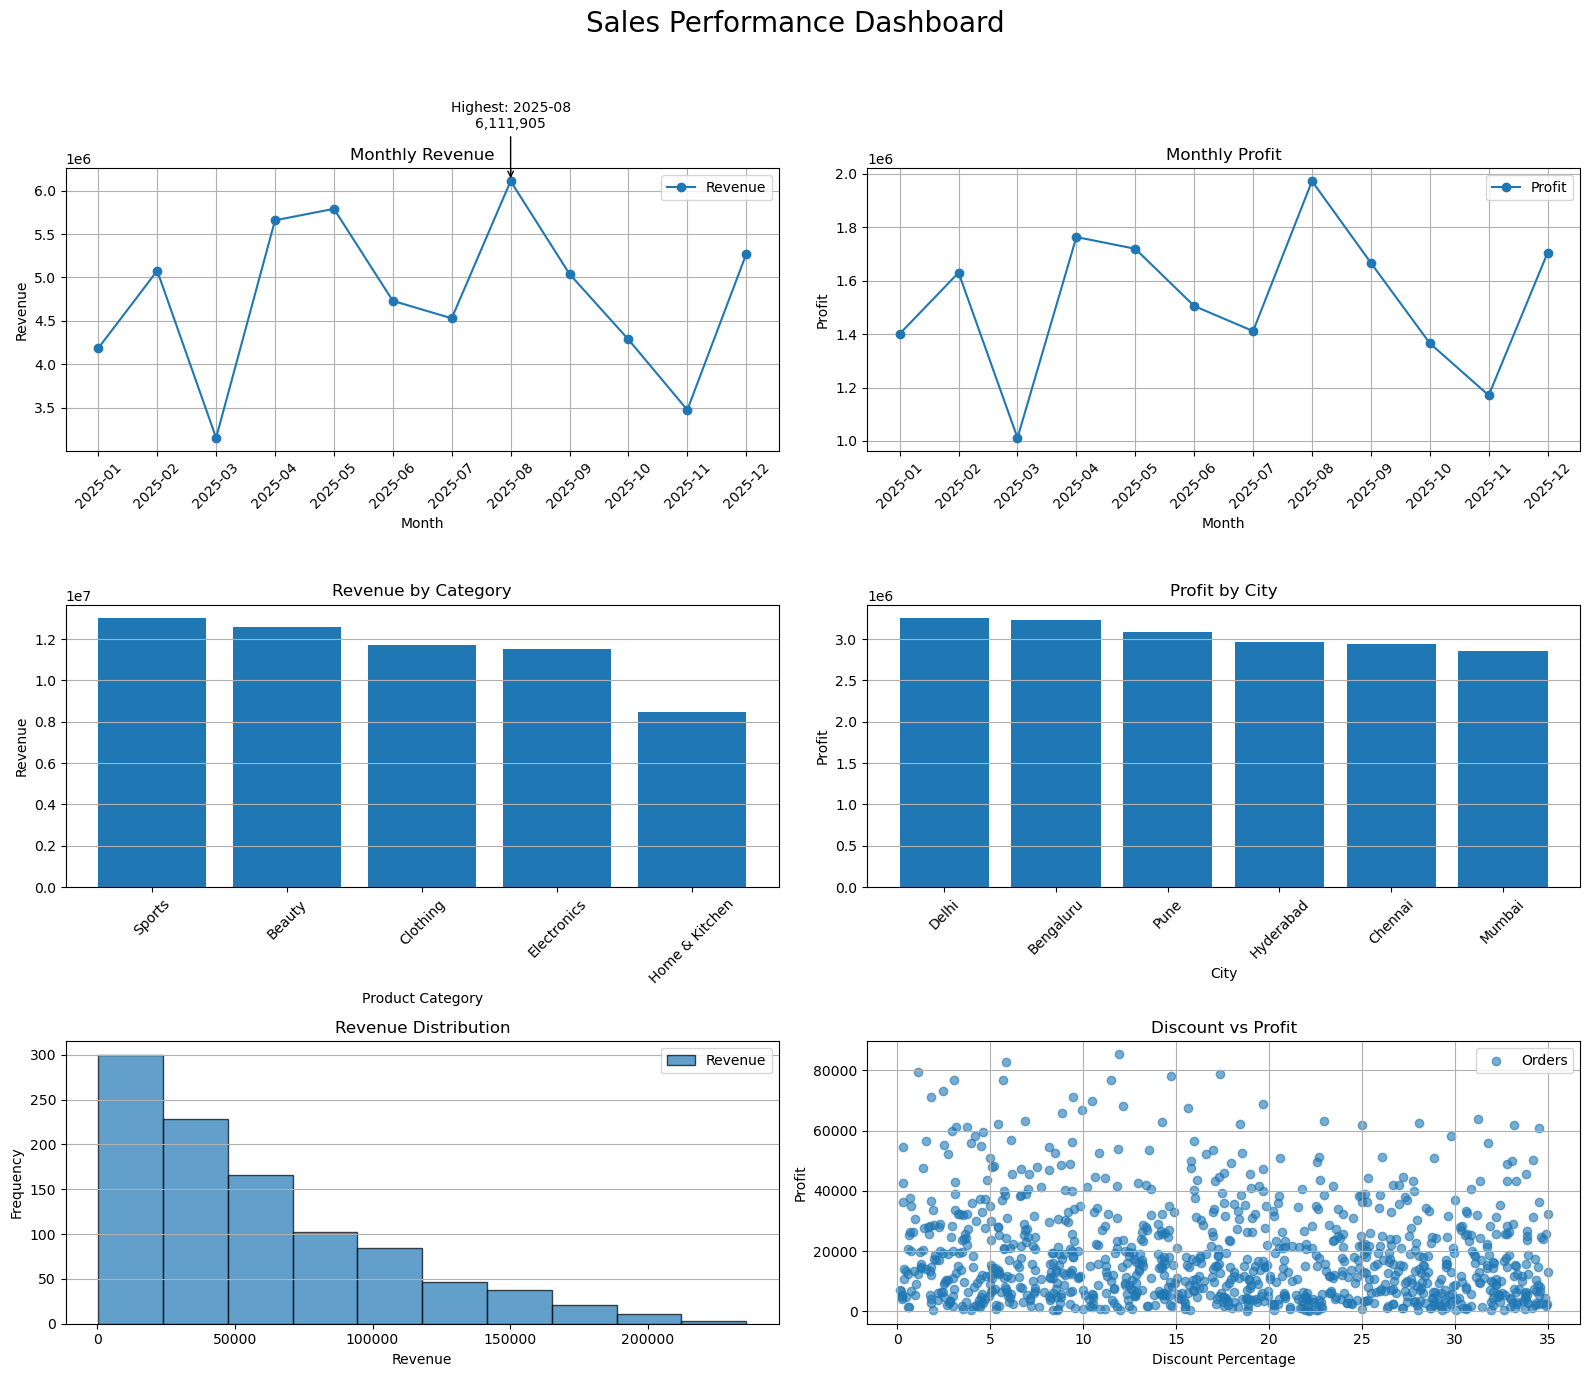

In [45]:
# 29. Create a complete sales performance dashboard with:
#o Monthly Revenue
#o Monthly Profit
#o Revenue by Category
#o Profit by City
#o Revenue distribution
#o Discount vs Profit
#Add titles, labels, legends, grids, annotations, and appropriate figure sizing.

import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# -----------------------------
# Prepare data
# -----------------------------

# Monthly Revenue and Profit
monthly_data = df.pivot_table(
    index=df["Order_Date"].dt.to_period("M"),
    values=["Revenue", "Profit"],
    aggfunc="sum"
)

# Revenue by Category
category_revenue = df.pivot_table(
    index="Product_Category",
    values="Revenue",
    aggfunc="sum"
).sort_values("Revenue", ascending=False)

# Profit by City
city_profit = df.pivot_table(
    index="City",
    values="Profit",
    aggfunc="sum"
).sort_values("Profit", ascending=False)


# -----------------------------
# Create 3×2 dashboard
# -----------------------------

fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 14)
)

# 1. Monthly Revenue
months = monthly_data.index.astype(str)

axes[0, 0].plot(
    months,
    monthly_data["Revenue"],
    marker="o",
    label="Revenue"
)

# Find highest revenue month
highest_month = monthly_data["Revenue"].idxmax()
highest_revenue = monthly_data.loc[highest_month, "Revenue"]
highest_position = list(monthly_data.index).index(highest_month)

# Annotation
axes[0, 0].annotate(
    f"Highest: {highest_month}\n{highest_revenue:,.0f}",
    xy=(highest_position, highest_revenue),
    xytext=(highest_position, highest_revenue * 1.10),
    arrowprops=dict(arrowstyle="->"),
    ha="center"
)

axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(True)
axes[0, 0].legend()


# 2. Monthly Profit
axes[0, 1].plot(
    months,
    monthly_data["Profit"],
    marker="o",
    label="Profit"
)

axes[0, 1].set_title("Monthly Profit")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Profit")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].grid(True)
axes[0, 1].legend()


# 3. Revenue by Category
axes[1, 0].bar(
    category_revenue.index,
    category_revenue["Revenue"]
)

axes[1, 0].set_title("Revenue by Category")
axes[1, 0].set_xlabel("Product Category")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(axis="y")


# 4. Profit by City
axes[1, 1].bar(
    city_profit.index,
    city_profit["Profit"]
)

axes[1, 1].set_title("Profit by City")
axes[1, 1].set_xlabel("City")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y")


# 5. Revenue Distribution
axes[2, 0].hist(
    df["Revenue"].dropna(),
    bins=10,
    edgecolor="black",
    alpha=0.7,
    label="Revenue"
)

axes[2, 0].set_title("Revenue Distribution")
axes[2, 0].set_xlabel("Revenue")
axes[2, 0].set_ylabel("Frequency")
axes[2, 0].grid(axis="y")
axes[2, 0].legend()


# 6. Discount vs Profit
axes[2, 1].scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6,
    label="Orders"
)

axes[2, 1].set_title("Discount vs Profit")
axes[2, 1].set_xlabel("Discount Percentage")
axes[2, 1].set_ylabel("Profit")
axes[2, 1].grid(True)
axes[2, 1].legend()


# Overall dashboard title
fig.suptitle(
    "Sales Performance Dashboard",
    fontsize=20
)

# Adjust spacing
plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

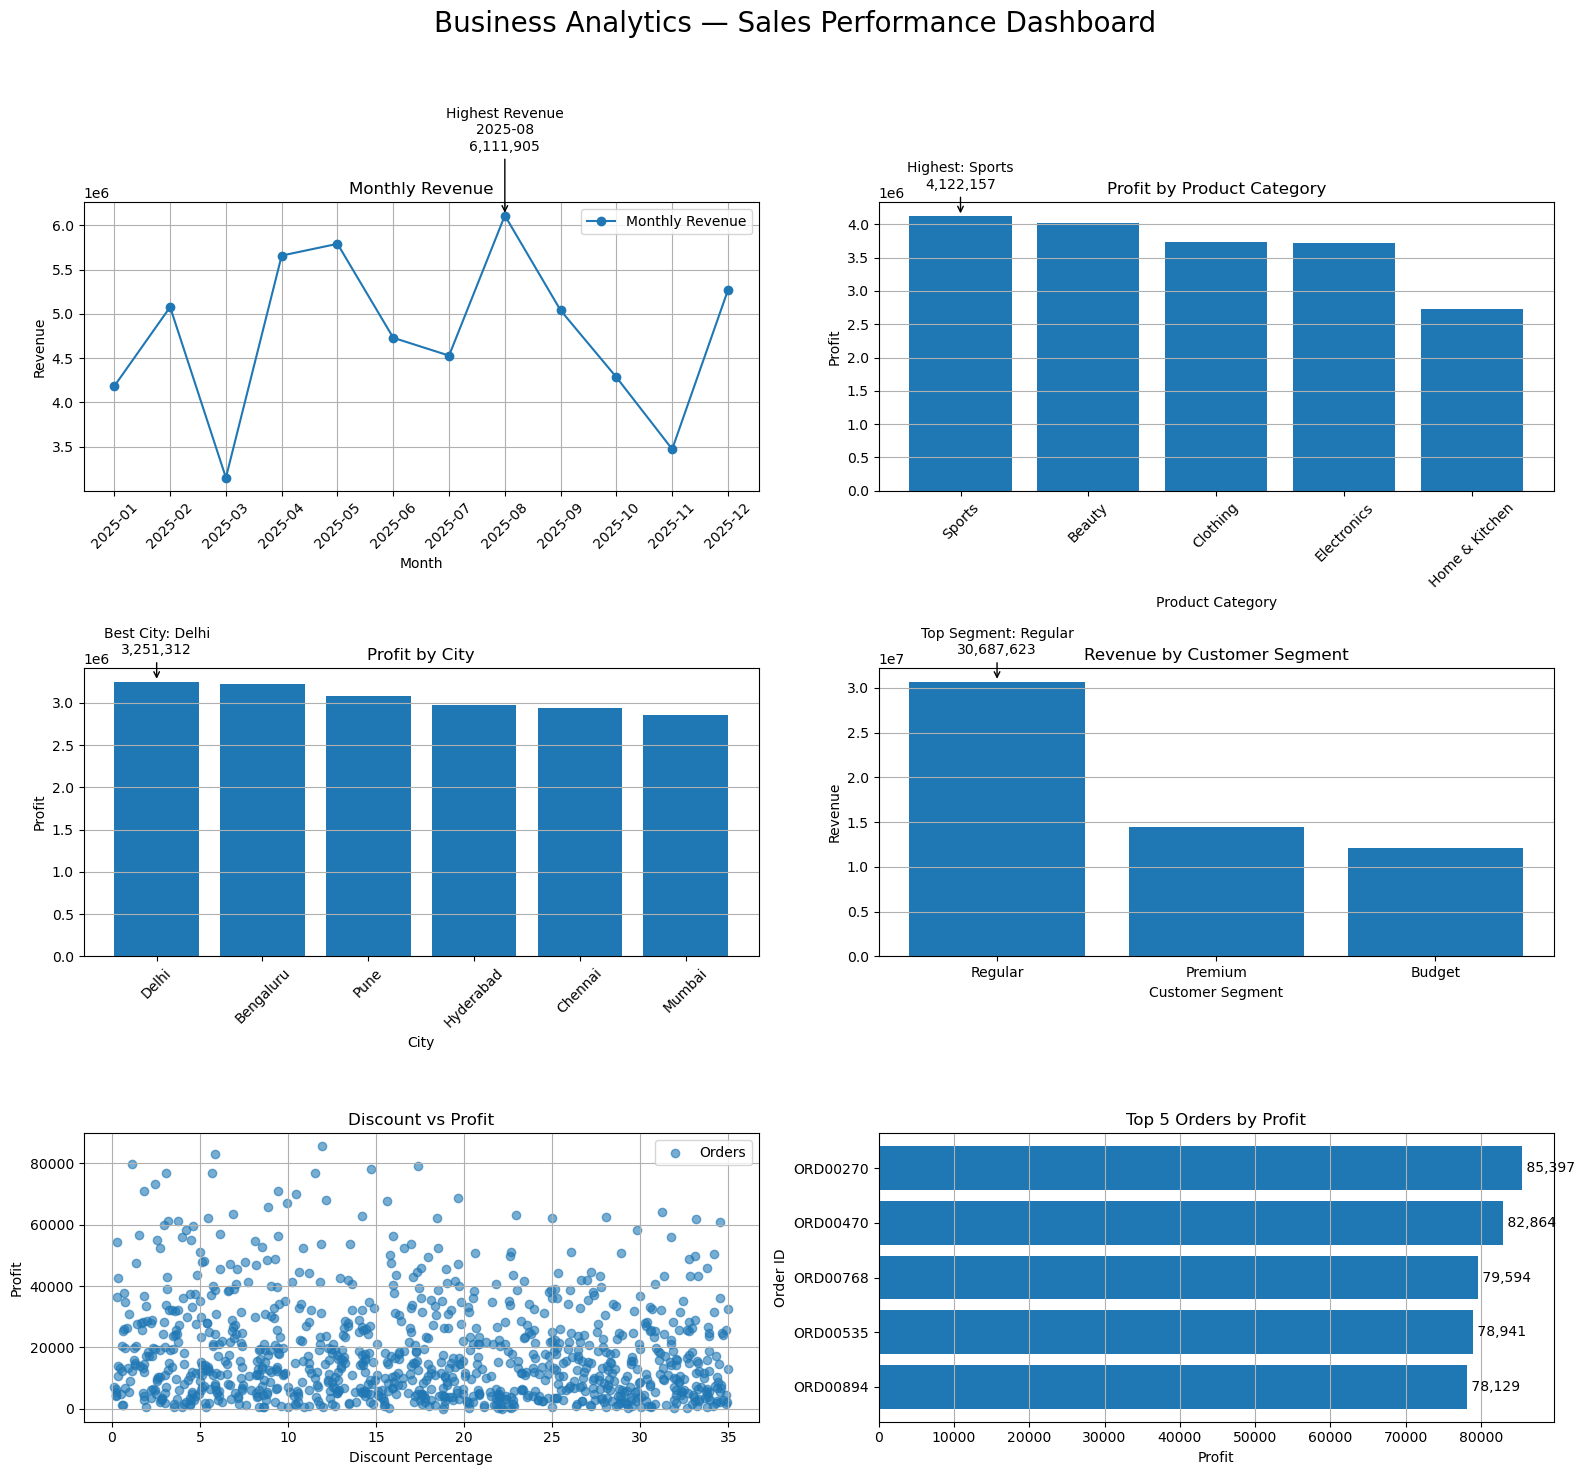

========== BUSINESS INSIGHTS ==========
1. Highest Revenue Month: 2025-08 | Revenue: 6,111,904.58
2. Highest Profit Category: Sports | Profit: 4,122,156.78
3. Best Performing City: Delhi | Profit: 3,251,311.52
4. Highest Revenue Customer Segment: Regular | Revenue: 30,687,622.79
5. Discount vs Profit: Check the scatter plot for the overall relationship.
6. Revenue Distribution: Check the distribution of order-level Revenue in the histogram.
7. Top 5 Orders by Profit:
Order_ID   Profit
ORD00894 78128.92
ORD00535 78940.69
ORD00768 79593.70
ORD00470 82864.07
ORD00270 85397.07


In [46]:
# 30. Final Challenge — Business Analytics Visualization
#Using the complete dataset, create a professional Matplotlib dashboard that answers:
#o Which month generated the highest revenue?
#o Which product category generated the highest profit?
#o Which city performed best?
#o Which customer segment generated the most revenue?
#o Does discount appear to affect profit?
#o What is the distribution of order revenue?
#o Which 5 orders generated the highest profit?
#Use at least 6 different visualizations, combine them into subplots, and add meaningful
#annotations to the important findings.

import pandas as pd
import matplotlib.pyplot as plt

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# =========================================================
# 1. PREPARE DATA
# =========================================================

# Monthly Revenue
monthly_revenue = df.pivot_table(
    index=df["Order_Date"].dt.to_period("M"),
    values="Revenue",
    aggfunc="sum"
)

# Profit by Product Category
category_profit = df.pivot_table(
    index="Product_Category",
    values="Profit",
    aggfunc="sum"
).sort_values("Profit", ascending=False)

# Profit by City
city_profit = df.pivot_table(
    index="City",
    values="Profit",
    aggfunc="sum"
).sort_values("Profit", ascending=False)

# Revenue by Customer Segment
segment_revenue = df.pivot_table(
    index="Customer_Segment",
    values="Revenue",
    aggfunc="sum"
).sort_values("Revenue", ascending=False)

# Top 5 orders by Profit
top_5_profit = df.nlargest(5, "Profit").sort_values("Profit")

# =========================================================
# 2. FIND IMPORTANT BUSINESS INSIGHTS
# =========================================================

highest_revenue_month = monthly_revenue["Revenue"].idxmax()
highest_month_revenue = monthly_revenue.loc[
    highest_revenue_month, "Revenue"
]

highest_profit_category = category_profit["Profit"].idxmax()
highest_category_profit = category_profit.loc[
    highest_profit_category, "Profit"
]

best_city = city_profit["Profit"].idxmax()
best_city_profit = city_profit.loc[
    best_city, "Profit"
]

top_customer_segment = segment_revenue["Revenue"].idxmax()
top_segment_revenue = segment_revenue.loc[
    top_customer_segment, "Revenue"
]

# =========================================================
# 3. CREATE 3×2 DASHBOARD
# =========================================================

fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 15)
)

# =========================================================
# CHART 1 — MONTHLY REVENUE
# =========================================================

months = monthly_revenue.index.astype(str)

axes[0, 0].plot(
    months,
    monthly_revenue["Revenue"],
    marker="o",
    label="Monthly Revenue"
)

# Find position of highest revenue month
highest_position = list(
    monthly_revenue.index
).index(highest_revenue_month)

# Annotate highest revenue month
axes[0, 0].annotate(
    f"Highest Revenue\n"
    f"{highest_revenue_month}\n"
    f"{highest_month_revenue:,.0f}",
    xy=(highest_position, highest_month_revenue),
    xytext=(
        highest_position,
        highest_month_revenue * 1.12
    ),
    arrowprops=dict(arrowstyle="->"),
    ha="center"
)

axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].tick_params(
    axis="x",
    rotation=45
)
axes[0, 0].grid(True)
axes[0, 0].legend()


# =========================================================
# CHART 2 — PROFIT BY PRODUCT CATEGORY
# =========================================================

axes[0, 1].bar(
    category_profit.index,
    category_profit["Profit"]
)

# Highlight highest-profit category
axes[0, 1].annotate(
    f"Highest: {highest_profit_category}\n"
    f"{highest_category_profit:,.0f}",
    xy=(
        0,
        highest_category_profit
    ),
    xytext=(
        0,
        highest_category_profit * 1.10
    ),
    arrowprops=dict(arrowstyle="->"),
    ha="center"
)

axes[0, 1].set_title("Profit by Product Category")
axes[0, 1].set_xlabel("Product Category")
axes[0, 1].set_ylabel("Profit")
axes[0, 1].tick_params(
    axis="x",
    rotation=45
)
axes[0, 1].grid(axis="y")


# =========================================================
# CHART 3 — PROFIT BY CITY
# =========================================================

axes[1, 0].bar(
    city_profit.index,
    city_profit["Profit"]
)

# Annotate best-performing city
best_city_position = list(
    city_profit.index
).index(best_city)

axes[1, 0].annotate(
    f"Best City: {best_city}\n"
    f"{best_city_profit:,.0f}",
    xy=(
        best_city_position,
        best_city_profit
    ),
    xytext=(
        best_city_position,
        best_city_profit * 1.10
    ),
    arrowprops=dict(arrowstyle="->"),
    ha="center"
)

axes[1, 0].set_title("Profit by City")
axes[1, 0].set_xlabel("City")
axes[1, 0].set_ylabel("Profit")
axes[1, 0].tick_params(
    axis="x",
    rotation=45
)
axes[1, 0].grid(axis="y")


# =========================================================
# CHART 4 — REVENUE BY CUSTOMER SEGMENT
# =========================================================

axes[1, 1].bar(
    segment_revenue.index,
    segment_revenue["Revenue"]
)

# Annotate highest-revenue segment
top_segment_position = list(
    segment_revenue.index
).index(top_customer_segment)

axes[1, 1].annotate(
    f"Top Segment: {top_customer_segment}\n"
    f"{top_segment_revenue:,.0f}",
    xy=(
        top_segment_position,
        top_segment_revenue
    ),
    xytext=(
        top_segment_position,
        top_segment_revenue * 1.10
    ),
    arrowprops=dict(arrowstyle="->"),
    ha="center"
)

axes[1, 1].set_title("Revenue by Customer Segment")
axes[1, 1].set_xlabel("Customer Segment")
axes[1, 1].set_ylabel("Revenue")
axes[1, 1].grid(axis="y")


# =========================================================
# CHART 5 — DISCOUNT VS PROFIT
# =========================================================

axes[2, 0].scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6,
    label="Orders"
)

axes[2, 0].set_title(
    "Discount vs Profit"
)
axes[2, 0].set_xlabel(
    "Discount Percentage"
)
axes[2, 0].set_ylabel(
    "Profit"
)
axes[2, 0].grid(True)
axes[2, 0].legend()


# =========================================================
# CHART 6 — TOP 5 ORDERS BY PROFIT
# =========================================================

axes[2, 1].barh(
    top_5_profit["Order_ID"].astype(str),
    top_5_profit["Profit"]
)

axes[2, 1].set_title(
    "Top 5 Orders by Profit"
)
axes[2, 1].set_xlabel("Profit")
axes[2, 1].set_ylabel("Order ID")
axes[2, 1].grid(axis="x")

# Add profit values beside bars
for i, profit in enumerate(
    top_5_profit["Profit"]
):
    axes[2, 1].text(
        profit,
        i,
        f" {profit:,.0f}",
        va="center"
    )


# =========================================================
# OVERALL DASHBOARD TITLE
# =========================================================

fig.suptitle(
    "Business Analytics — Sales Performance Dashboard",
    fontsize=20
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()


# =========================================================
# PRINT BUSINESS INSIGHTS
# =========================================================

print("========== BUSINESS INSIGHTS ==========")

print(
    "1. Highest Revenue Month:",
    highest_revenue_month,
    "| Revenue:",
    f"{highest_month_revenue:,.2f}"
)

print(
    "2. Highest Profit Category:",
    highest_profit_category,
    "| Profit:",
    f"{highest_category_profit:,.2f}"
)

print(
    "3. Best Performing City:",
    best_city,
    "| Profit:",
    f"{best_city_profit:,.2f}"
)

print(
    "4. Highest Revenue Customer Segment:",
    top_customer_segment,
    "| Revenue:",
    f"{top_segment_revenue:,.2f}"
)

print(
    "5. Discount vs Profit:",
    "Check the scatter plot for the overall relationship."
)

print(
    "6. Revenue Distribution:",
    "Check the distribution of order-level Revenue in the histogram."
)

print("7. Top 5 Orders by Profit:")

print(
    top_5_profit[
        ["Order_ID", "Profit"]
    ].to_string(index=False)
)